<a href="https://colab.research.google.com/github/candelalespada/study-habits-predictor/blob/main/StudyHabitsPredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score,
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

csv_path = "merged.csv"
df = pd.read_csv(csv_path)

if "Percent" not in df.columns:
    df["Percent"] = df["Total Score"] / df["Max Points"] * 100

if "Letter" not in df.columns:

    def pct_to_letter(p):
        if p >= 90:
            return "A"
        elif p >= 80:
            return "B"
        elif p >= 70:
            return "C"
        elif p >= 60:
            return "D"
        else:
            return "F"

    df["Letter"] = df["Percent"].apply(pct_to_letter)

if "PassFail" not in df.columns:
    df["PassFail"] = df["Letter"].apply(
        lambda g: "Pass" if g in ["A", "B", "C"] else "Fail"
    )

print("\nGrade distribution:")
print(df["Letter"].value_counts())
print("\nPass/Fail distribution:")
print(df["PassFail"].value_counts())

dropped_cols = [
    "Unnamed: 0",
    "Timestamp",
    "Total Score",
    "Max Points",
    "Percent",
    "Letter",
    "PassFail",
]

dropped_cols = [c for c in dropped_cols if c in df.columns]

feature_cols = [c for c in df.columns if c not in dropped_cols]
XBefore = df[feature_cols]

#one-hot encode
X = pd.get_dummies(XBefore, drop_first=True)

print("\nFeature matrix shape after get_dummies:", X.shape)

#pass vs. fail

y_passfail = df["PassFail"]

X_train_passfail, X_test_passfail, y_train_passfail, y_test_passfail = train_test_split(
    X, y_passfail, test_size=0.2, stratify = y_passfail, random_state=0
)

pf_models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000)),
        ]
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=None, random_state=0
    ),
    "KNN (k=5)": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5)),
        ]
    ),
}

for name, model in pf_models.items():
    print("\n---", name, "---")
    model.fit(X_train_passfail, y_train_passfail)
    y_pred_passfail = model.predict(X_test_passfail)

    acc = accuracy_score(y_test_passfail, y_pred_passfail)
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test_passfail, y_pred_passfail, digits=3))

# letter grades
y_letter = df["Letter"]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X, y_letter, test_size=0.2, stratify=y_letter, random_state=0
)

letter_models = {
    "Multinomial Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    multi_class="multinomial",
                    max_iter=1000,
                ),
            ),
        ]
    ),
    "Decision Tree": DecisionTreeClassifier(
    max_depth=None, random_state=0
    ),
     "KNN (k=5)": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5)),
        ]
    ),
}

for name, model in letter_models.items():
    print("\n---", name, "---")
    model.fit(X_train_l, y_train_l)
    y_pred_l = model.predict(X_test_l)

    acc = accuracy_score(y_test_l, y_pred_l)
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test_l, y_pred_l, digits=3))

    labels = ["A", "B", "C", "D", "F"]

#regression
print("\n" + "=" * 60)
print("REGRESSION – Predict Percent Score")
print("=" * 60)

y_reg = df["Percent"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=0
)

reg_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("reg", LinearRegression()),
    ]
)

reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")


Grade distribution:
Letter
F    63
D    49
C    42
B    30
A     4
Name: count, dtype: int64

Pass/Fail distribution:
PassFail
Fail    112
Pass     76
Name: count, dtype: int64

Feature matrix shape after get_dummies: (188, 21)

--- Logistic Regression ---
Accuracy: 0.553
              precision    recall  f1-score   support

        Fail      0.636     0.609     0.622        23
        Pass      0.438     0.467     0.452        15

    accuracy                          0.553        38
   macro avg      0.537     0.538     0.537        38
weighted avg      0.558     0.553     0.555        38


--- Decision Tree ---
Accuracy: 0.526
              precision    recall  f1-score   support

        Fail      0.619     0.565     0.591        23
        Pass      0.412     0.467     0.438        15

    accuracy                          0.526        38
   macro avg      0.515     0.516     0.514        38
weighted avg      0.537     0.526     0.530        38


--- KNN (k=5) ---
Accuracy: 0.57

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

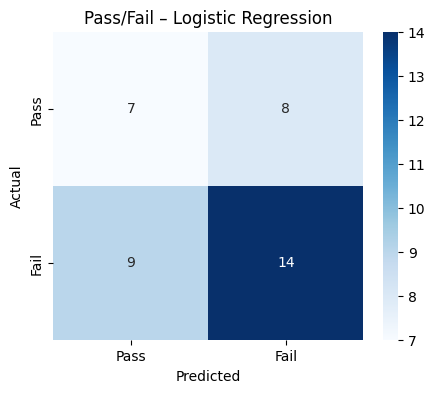

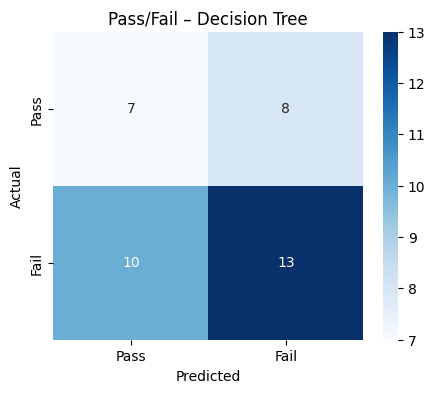

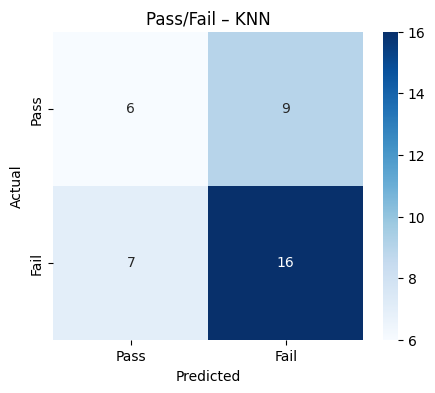

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_conf_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Logistic Regression
plot_conf_matrix(y_test_pf, pf_models["Logistic Regression"].predict(X_test_pf),
                 ["Pass","Fail"], "Pass/Fail – Logistic Regression")

# Decision Tree
plot_conf_matrix(y_test_pf, pf_models["Decision Tree"].predict(X_test_pf),
                 ["Pass","Fail"], "Pass/Fail – Decision Tree")

# KNN
plot_conf_matrix(y_test_pf, pf_models["KNN (k=5)"].predict(X_test_pf),
                 ["Pass","Fail"], "Pass/Fail – KNN")


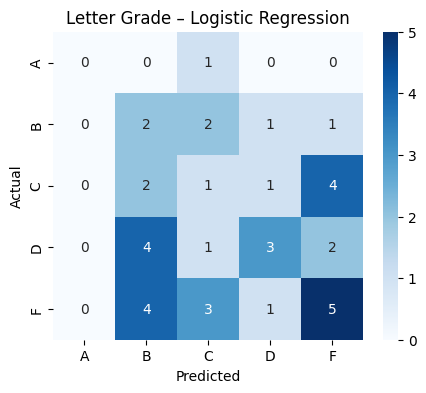

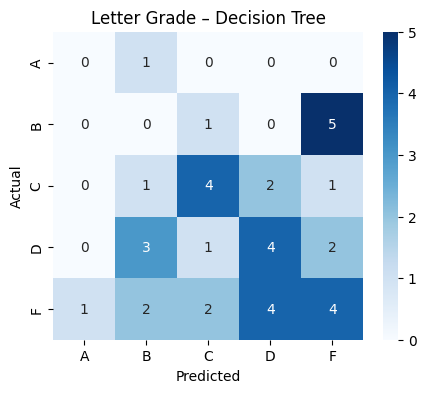

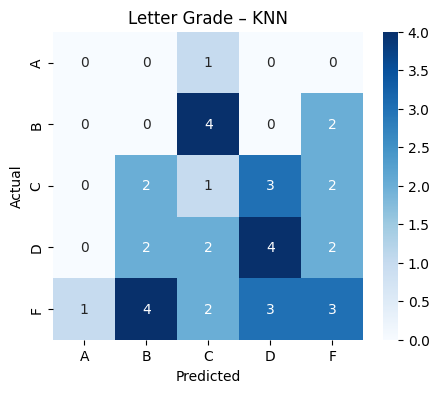

In [ ]:
labels = ["A","B","C","D","F"]

# Logistic Regression (letter-grade)
plot_conf_matrix(y_test_l, letter_models["Multinomial Logistic Regression"].predict(X_test_l),
                 labels, "Letter Grade – Logistic Regression")

# Decision Tree (letter-grade)
plot_conf_matrix(y_test_l, letter_models["Decision Tree"].predict(X_test_l),
                 labels, "Letter Grade – Decision Tree")

plot_conf_matrix(
    y_test_l,
    letter_models["KNN (k=5)"].predict(X_test_l),
    labels,
    "Letter Grade – KNN"
)


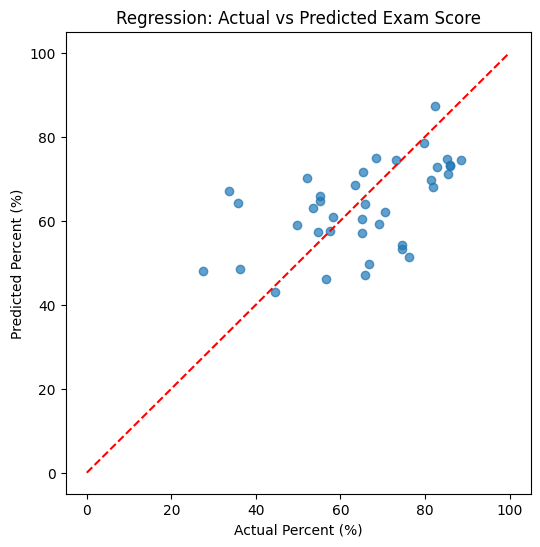

In [ ]:
# Get predictions
y_pred_r = reg_model.predict(X_test_r)

plt.figure(figsize=(6,6))
plt.scatter(y_test_r, y_pred_r, alpha=0.7)
plt.plot([0,100],[0,100],'r--')  # perfect prediction line
plt.xlabel("Actual Percent (%)")
plt.ylabel("Predicted Percent (%)")
plt.title("Regression: Actual vs Predicted Exam Score")
plt.show()
